In [7]:
import os
print(os.listdir())

['.config', 'Insect Classification-20260417T174825Z-3-001.zip', 'intel_data', 'sample_data']


In [8]:
import zipfile, os

zip_path   = '/content/Insect Classification-20260417T174825Z-3-001.zip'   # change if in Drive
extract_to = '/content/intel_data'

os.makedirs(extract_to, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print('Done! Contents:')
for item in os.listdir(extract_to):
    print(' ', item)

print(os.listdir(os.path.join(os.getcwd(), extract_to,'Insect Classification')))

Done! Contents:
  Insect Classification
['train', 'test']


# 6CS012 - Image Classification with CNN
## Intel Image Classification Dataset
**Herald College Kathmandu | Tribhuvan University**

---
### Dataset Folder Structure:
```
intel_data/
├── seg_train/seg_train/   ← Training images
├── seg_test/seg_test/     ← Test images
└── seg_pred/seg_pred/     ← Prediction images (no labels)
```

---
## 🔧 Setup: Mount Drive & Install Libraries

In [9]:
# ============================================================
# SET YOUR DATASET PATH HERE
# Example if on Drive: '/content/drive/MyDrive/intel_data'
# Example if uploaded directly: '/content/intel_data'
# ============================================================
BASE_DIR  = '/content/intel_data/Insect Classification'
TRAIN_DIR = '/content/intel_data/Insect Classification/train'
TEST_DIR  = '/content/intel_data/Insect Classification/test'


# Verify paths exist
for path, name in [(TRAIN_DIR,'Train'), (TEST_DIR,'Test')]:
    exists = os.path.exists(path)
    print(f'{name} path exists: {exists} -> {path}')

Train path exists: True -> /content/intel_data/Insect Classification/train
Test path exists: True -> /content/intel_data/Insect Classification/test


In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import time
import warnings
warnings.filterwarnings('ignore')

from PIL import Image
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version: 2.19.0
GPU available: True


---
## 📊 Part A - Section 1: Data Understanding, Analysis & Visualization

In [11]:
# Get class names
CLASSES = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(CLASSES)
print(f'Classes: {CLASSES}')
print(f'Number of classes: {NUM_CLASSES}')

Classes: ['aphids', 'armyworm', 'beetle', 'bollworm', 'grasshopper', 'mites', 'mosquito', 'sawfly', 'stem_borer']
Number of classes: 9


In [12]:
# Count images per class
print('=== IMAGE COUNT PER CLASS ===')
train_counts = {}
test_counts  = {}
total_train  = 0
total_test   = 0

for cls in CLASSES:
    t = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    e = len(os.listdir(os.path.join(TEST_DIR,  cls)))
    train_counts[cls] = t
    test_counts[cls]  = e
    total_train += t
    total_test  += e
    print(f'  {cls:<12} | Train: {t:>5} | Test: {e:>4}')

print(f'\n  {"TOTAL":<12} | Train: {total_train:>5} | Test: {total_test:>4}')
print(f'  Grand Total: {total_train + total_test} images')

=== IMAGE COUNT PER CLASS ===
  aphids       | Train:   266 | Test:   44
  armyworm     | Train:   223 | Test:   43
  beetle       | Train:   291 | Test:   50
  bollworm     | Train:   245 | Test:   36
  grasshopper  | Train:   277 | Test:   46
  mites        | Train:   254 | Test:   42
  mosquito     | Train:   295 | Test:   50
  sawfly       | Train:   200 | Test:   37
  stem_borer   | Train:   181 | Test:   36

  TOTAL        | Train:  2232 | Test:  384
  Grand Total: 2616 images


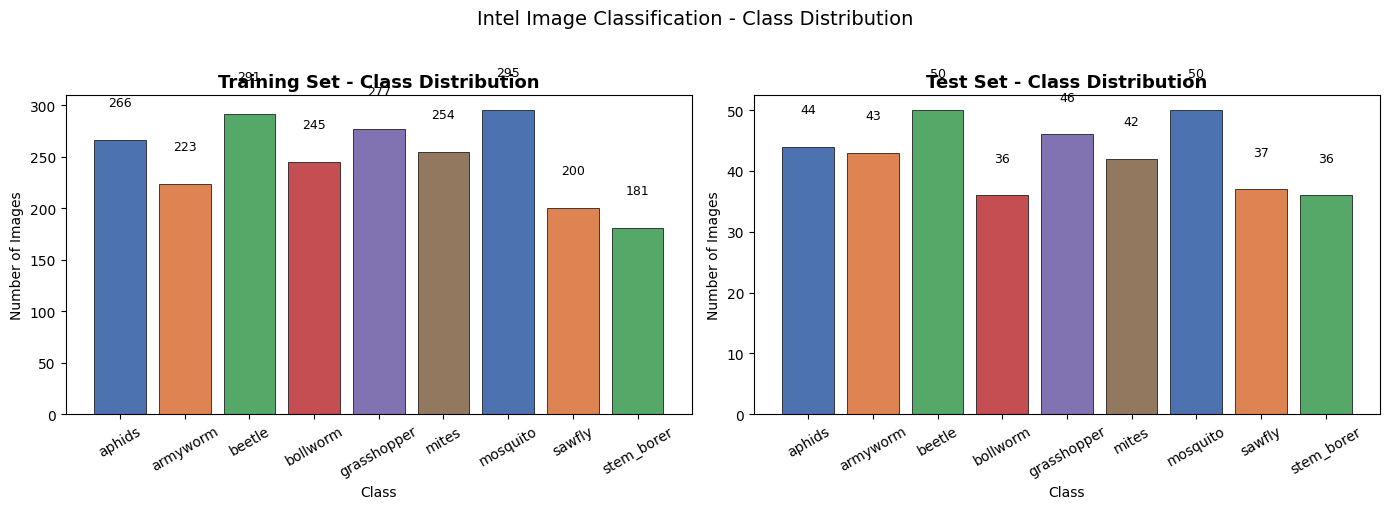

In [13]:
# Plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']

bars1 = axes[0].bar(train_counts.keys(), train_counts.values(), color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Training Set - Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Number of Images')
axes[0].tick_params(axis='x', rotation=30)
for bar, count in zip(bars1, train_counts.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 str(count), ha='center', va='bottom', fontsize=9)

bars2 = axes[1].bar(test_counts.keys(), test_counts.values(), color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_title('Test Set - Class Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Number of Images')
axes[1].tick_params(axis='x', rotation=30)
for bar, count in zip(bars2, test_counts.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(count), ha='center', va='bottom', fontsize=9)

plt.suptitle('Intel Image Classification - Class Distribution', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
print("=== POST-CLEANING CLASS COUNTS ===")
for cls in sorted(os.listdir(TRAIN_DIR)):
    cls_path = os.path.join(TRAIN_DIR, cls)
    if os.path.isdir(cls_path):
        count = len(os.listdir(cls_path))
        print(f"  {cls:<15} | Train: {count}")

print()
for cls in sorted(os.listdir(TEST_DIR)):
    cls_path = os.path.join(TEST_DIR, cls)
    if os.path.isdir(cls_path):
        count = len(os.listdir(cls_path))
        print(f"  {cls:<15} | Test: {count}")

=== POST-CLEANING CLASS COUNTS ===
  aphids          | Train: 266
  armyworm        | Train: 223
  beetle          | Train: 291
  bollworm        | Train: 245
  grasshopper     | Train: 277
  mites           | Train: 254
  mosquito        | Train: 295
  sawfly          | Train: 200
  stem_borer      | Train: 181

  aphids          | Test: 44
  armyworm        | Test: 43
  beetle          | Test: 50
  bollworm        | Test: 36
  grasshopper     | Test: 46
  mites           | Test: 42
  mosquito        | Test: 50
  sawfly          | Test: 37
  stem_borer      | Test: 36


In [15]:
from PIL import Image, UnidentifiedImageError
import os

def clean_dataset(directory, label=""):
    removed = 0
    converted = 0
    kept = 0
    VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

    for cls in os.listdir(directory):
        cls_path = os.path.join(directory, cls)
        if not os.path.isdir(cls_path):
            continue
        for fname in os.listdir(cls_path):
            fpath = os.path.join(cls_path, fname)
            ext = os.path.splitext(fname)[1].lower()

            # Remove non-image files
            if ext not in VALID_EXTENSIONS:
                os.remove(fpath)
                print(f"  [REMOVED - not image] {fpath}")
                removed += 1
                continue

            # Try opening the image
            try:
                img = Image.open(fpath)
                img.verify()  # catches broken/truncated files

                # Re-open after verify (verify closes the file)
                img = Image.open(fpath)

                # Convert non-RGB to RGB (handles RGBA, grayscale etc.)
                if img.mode != 'RGB':
                    img = img.convert('RGB')
                    img.save(fpath)
                    converted += 1

                kept += 1

            except (UnidentifiedImageError, Exception) as e:
                os.remove(fpath)
                print(f"  [REMOVED - corrupt] {fname} | Reason: {e}")
                removed += 1

    print(f"\n{label} Cleaning Summary:")
    print(f"  Kept:      {kept}")
    print(f"  Converted to RGB: {converted}")
    print(f"  Removed:   {removed}")
    print(f"  Total processed: {kept + removed}")

print("Cleaning TRAIN directory...")
clean_dataset(TRAIN_DIR, "TRAIN")

print("\nCleaning TEST directory...")
clean_dataset(TEST_DIR, "TEST")

print("\nDone! Dataset is clean.")

Cleaning TRAIN directory...
  [REMOVED - corrupt] jpg_63 - Copy.jpg | Reason: cannot identify image file '/content/intel_data/Insect Classification/train/mosquito/jpg_63 - Copy.jpg'
  [REMOVED - corrupt] jpg_36 - Copy.jpg | Reason: cannot identify image file '/content/intel_data/Insect Classification/train/mosquito/jpg_36 - Copy.jpg'
  [REMOVED - corrupt] jpg_62 - Copy.jpg | Reason: cannot identify image file '/content/intel_data/Insect Classification/train/mosquito/jpg_62 - Copy.jpg'
  [REMOVED - corrupt] jpg_12 - Copy.jpg | Reason: cannot identify image file '/content/intel_data/Insect Classification/train/mosquito/jpg_12 - Copy.jpg'
  [REMOVED - corrupt] jpg_46.jpg | Reason: cannot identify image file '/content/intel_data/Insect Classification/train/mosquito/jpg_46.jpg'
  [REMOVED - corrupt] jpg_55.jpg | Reason: cannot identify image file '/content/intel_data/Insect Classification/train/mosquito/jpg_55.jpg'
  [REMOVED - corrupt] jpg_4.jpg | Reason: cannot identify image file '/conte

In [16]:
print("=== POST-CLEANING CLASS COUNTS ===")
for cls in sorted(os.listdir(TRAIN_DIR)):
    cls_path = os.path.join(TRAIN_DIR, cls)
    if os.path.isdir(cls_path):
        count = len(os.listdir(cls_path))
        print(f"  {cls:<15} | Train: {count}")

print()
for cls in sorted(os.listdir(TEST_DIR)):
    cls_path = os.path.join(TEST_DIR, cls)
    if os.path.isdir(cls_path):
        count = len(os.listdir(cls_path))
        print(f"  {cls:<15} | Test: {count}")

=== POST-CLEANING CLASS COUNTS ===
  aphids          | Train: 254
  armyworm        | Train: 210
  beetle          | Train: 277
  bollworm        | Train: 231
  grasshopper     | Train: 264
  mites           | Train: 240
  mosquito        | Train: 281
  sawfly          | Train: 186
  stem_borer      | Train: 168

  aphids          | Test: 44
  armyworm        | Test: 43
  beetle          | Test: 50
  bollworm        | Test: 36
  grasshopper     | Test: 46
  mites           | Test: 42
  mosquito        | Test: 50
  sawfly          | Test: 37
  stem_borer      | Test: 36


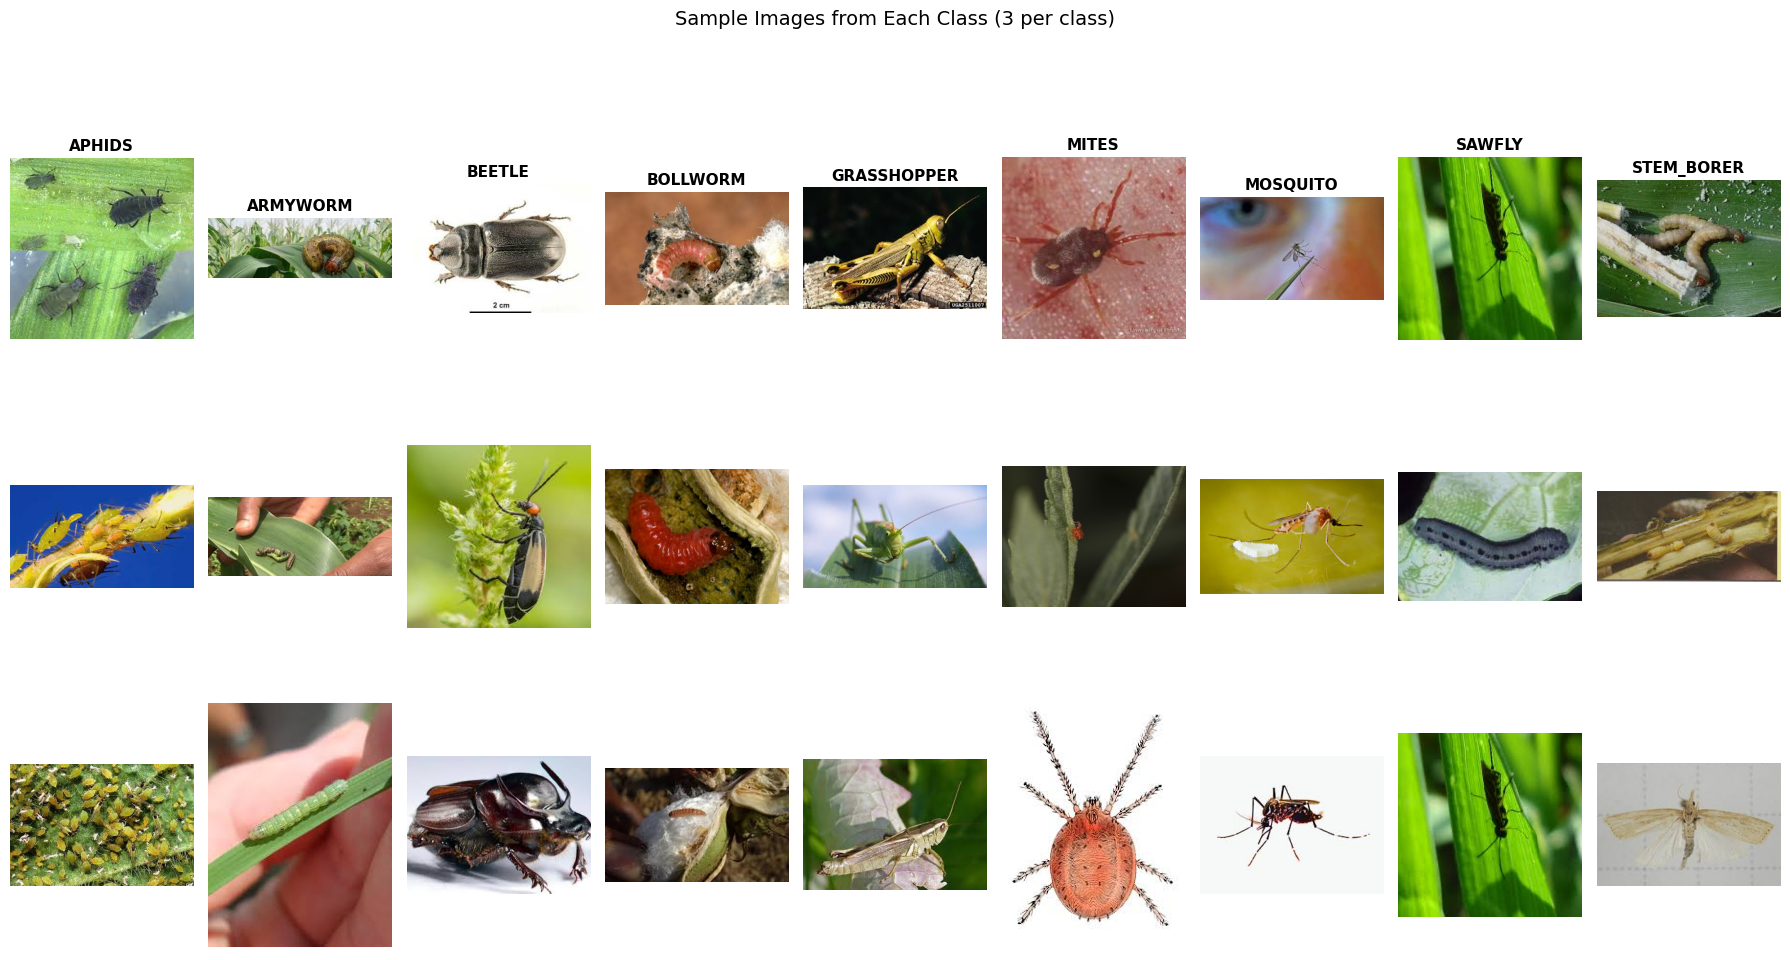

In [17]:
# Visualize sample images from each class
fig, axes = plt.subplots(3, NUM_CLASSES, figsize=(18, 10))

for col, cls in enumerate(CLASSES):
    cls_path = os.path.join(TRAIN_DIR, cls)
    images   = os.listdir(cls_path)
    for row in range(3):
        img = Image.open(os.path.join(cls_path, random.choice(images)))
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if row == 0:
            axes[row][col].set_title(cls.upper(), fontsize=11, fontweight='bold', pad=5)

plt.suptitle('Sample Images from Each Class (3 per class)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Check image sizes and properties
sizes = []
for cls in CLASSES:
    cls_path = os.path.join(TRAIN_DIR, cls)
    for img_name in os.listdir(cls_path)[:10]:
        img = Image.open(os.path.join(cls_path, img_name))
        sizes.append(img.size)

unique_sizes = Counter(sizes)
print(f'Unique image sizes found: {len(unique_sizes)}')
print(f'Most common sizes: {unique_sizes.most_common(5)}')
print(f'All images will be resized to 150x150 for training')

Unique image sizes found: 61
Most common sizes: [((275, 183), 10), ((225, 225), 8), ((300, 168), 5), ((259, 194), 3), ((183, 275), 3)]
All images will be resized to 150x150 for training


---
## 🔄 Data Preprocessing & Augmentation

In [19]:
# Hyperparameters
IMG_SIZE   = (150, 150)
BATCH_SIZE = 32
EPOCHS_BASELINE = 20
EPOCHS_DEEP     = 25

# Training generator WITH augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.1
)

# Validation & Test - only rescale (NO augmentation)
val_test_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Create generators
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_gen = val_test_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

CLASS_NAMES = list(train_gen.class_indices.keys())
print(f'\nClass indices: {train_gen.class_indices}')
print(f'Training samples:   {train_gen.samples}')
print(f'Validation samples: {val_gen.samples}')
print(f'Test samples:       {test_gen.samples}')

Found 1692 images belonging to 9 classes.
Found 419 images belonging to 9 classes.
Found 384 images belonging to 9 classes.

Class indices: {'aphids': 0, 'armyworm': 1, 'beetle': 2, 'bollworm': 3, 'grasshopper': 4, 'mites': 5, 'mosquito': 6, 'sawfly': 7, 'stem_borer': 8}
Training samples:   1692
Validation samples: 419
Test samples:       384


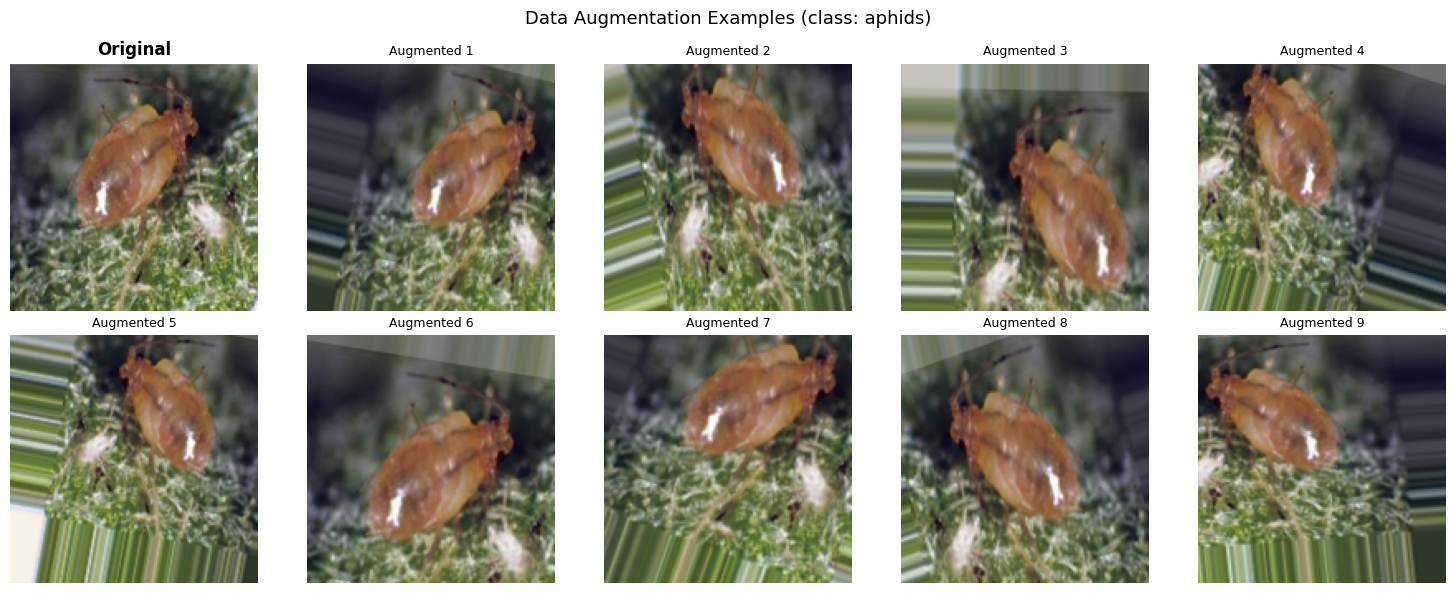

In [20]:
# Visualize augmented images
aug_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

# Pick a sample image
sample_cls  = CLASSES[0]
sample_path = os.path.join(TRAIN_DIR, sample_cls)
sample_img  = Image.open(os.path.join(sample_path, os.listdir(sample_path)[0]))
sample_arr  = np.array(sample_img.resize(IMG_SIZE)).reshape(1, 150, 150, 3)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes[0][0].imshow(sample_img.resize(IMG_SIZE))
axes[0][0].set_title('Original', fontweight='bold')
axes[0][0].axis('off')

aug_iter = aug_datagen.flow(sample_arr, batch_size=1)
for i, ax in enumerate(axes.flat):
    if i == 0: continue
    aug_img = next(aug_iter)[0]
    ax.imshow(aug_img)
    ax.set_title(f'Augmented {i}', fontsize=9)
    ax.axis('off')

plt.suptitle(f'Data Augmentation Examples (class: {sample_cls})', fontsize=13)
plt.tight_layout()
plt.savefig('augmentation_samples.png', dpi=150)
plt.show()

---
## 🏗️ Part A - Section 2: Baseline CNN Model (From Scratch)
Architecture: **3 Conv layers + 3 Fully Connected layers**

In [21]:
def build_baseline_model(input_shape=(150, 150, 3), num_classes=9):
    model = models.Sequential(name='Baseline_CNN')

    # --- Convolutional Block 1 ---
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape))
    model.add(layers.MaxPooling2D((2, 2)))

    # --- Convolutional Block 2 ---
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))

    # --- Convolutional Block 3 ---
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))

    # --- Flatten ---
    model.add(layers.Flatten())

    # --- Fully Connected Layers ---
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(64,  activation='relu'))

    # --- Output Layer ---
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

baseline_model = build_baseline_model()
baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    10,617,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,752,073 (41.02 MB)

 Trainable params: 10,752,073 (41.02 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Compile baseline model
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_baseline = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

print('Baseline model compiled. Starting training...')

Baseline model compiled. Starting training...


In [23]:
# Train baseline model
start_time_baseline = time.time()

history_baseline = baseline_model.fit(
    train_gen,
    epochs=EPOCHS_BASELINE,
    validation_data=val_gen,
    callbacks=callbacks_baseline,
    verbose=1
)

baseline_train_time = time.time() - start_time_baseline
print(f'\nBaseline training time: {baseline_train_time:.1f} seconds ({baseline_train_time/60:.1f} minutes)')

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 28s 383ms/step - accuracy: 0.1661 - loss: 2.1967 - val_accuracy: 0.2625 - val_loss: 2.0637 - learning_rate: 0.0010
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 273ms/step - accuracy: 0.2512 - loss: 2.0382 - val_accuracy: 0.2792 - val_loss: 2.0045 - learning_rate: 0.0010
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 275ms/step - accuracy: 0.2736 - loss: 1.9164 - val_accuracy: 0.3126 - val_loss: 1.8641 - learning_rate: 0.0010
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 281ms/step - accuracy: 0.3463 - loss: 1.7869 - val_accuracy: 0.3031 - val_loss: 1.9814 - learning_rate: 0.0010
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 273ms/step - accuracy: 0.3670 - loss: 1.7269 - val_accuracy: 0.3294 - val_loss: 1.8665 - learning_rate: 0.0010
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 14s 271ms/step - accuracy: 0.4255 - loss: 1.6135 - val_accuracy: 0.4320 - val_loss: 1.7272 - learning_rate: 0.0010
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 14s 272ms/step - accuracy: 0.4574 - loss: 1.

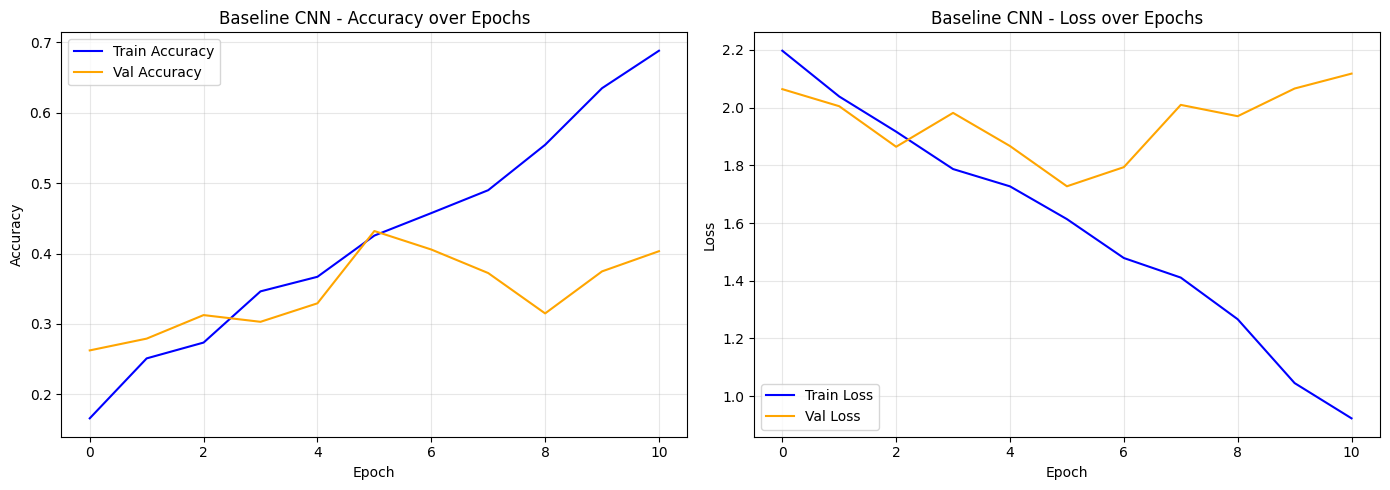

In [24]:
# Plot baseline training curves
def plot_history(history, title='Model'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train Accuracy',     color='blue')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',       color='orange')
    axes[0].set_title(f'{title} - Accuracy over Epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'],     label='Train Loss', color='blue')
    axes[1].plot(history.history['val_loss'], label='Val Loss',   color='orange')
    axes[1].set_title(f'{title} - Loss over Epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{title.replace(" ","_")}_curves.png', dpi=150)
    plt.show()

plot_history(history_baseline, 'Baseline CNN')

---
## 📉 Gradient Descent – Loss Surface & Convergence Visualisation
The cell below generates a **conceptual 2-D loss surface** with gradient-descent trajectories for both SGD and Adam, illustrating how each optimiser navigates towards the local minimum.

In [ ]:
# ── Gradient Descent: 2D Contour (all models) + 1-Weight Plot + 3D Surface ──
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(42)

# ── Shared loss surface (Rosenbrock-inspired, same as original) ───────────────
def loss_surface(w1, w2):
    return (1 - w1)**2 + 100*(w2 - w1**2)**2 * 0.02 + 0.3*np.sin(5*w1)*np.cos(5*w2)

W1      = np.linspace(-1.5, 1.5, 400)
W2      = np.linspace(-0.5, 2.0, 400)
W1g, W2g = np.meshgrid(W1, W2)
Z       = loss_surface(W1g, W2g)

# ── Optimiser simulators ──────────────────────────────────────────────────────
def grad(w):
    dw1 = -2*(1 - w[0]) - 400*w[0]*(w[1] - w[0]**2)*0.02 + 0.08*np.cos(5*w[0])
    dw2 =  200*(w[1] - w[0]**2)*0.02 - 0.08*np.sin(5*w[1])
    return np.array([dw1, dw2])

def simulate_sgd(lr=0.005, steps=120, noise=0.04, start=(-1.2, 1.8)):
    w = np.array(start, dtype=float)
    path = [w.copy()]
    for _ in range(steps):
        g = grad(w) + np.random.randn(2)*noise
        w = w - lr * g
        path.append(w.copy())
    return np.array(path)

def simulate_adam(lr=0.05, steps=70, b1=0.9, b2=0.999, eps=1e-8, start=(-1.2, 1.8)):
    w = np.array(start, dtype=float)
    m, v = np.zeros(2), np.zeros(2)
    path = [w.copy()]
    for t in range(1, steps+1):
        g = grad(w)
        m = b1*m + (1-b1)*g
        v = b2*v + (1-b2)*g**2
        w = w - lr*(m/(1-b1**t)) / (np.sqrt(v/(1-b2**t)) + eps)
        path.append(w.copy())
    return np.array(path)

def simulate_sgd_momentum(lr=0.008, steps=100, momentum=0.9, noise=0.04, start=(-1.2, 1.8)):
    w = np.array(start, dtype=float)
    vel = np.zeros(2)
    path = [w.copy()]
    for _ in range(steps):
        g = grad(w) + np.random.randn(2)*noise
        vel = momentum*vel - lr*g
        w = w + vel
        path.append(w.copy())
    return np.array(path)

def simulate_rmsprop(lr=0.02, steps=80, decay=0.9, eps=1e-8, noise=0.03, start=(-1.2, 1.8)):
    w = np.array(start, dtype=float)
    cache = np.zeros(2)
    path = [w.copy()]
    for _ in range(steps):
        g = grad(w) + np.random.randn(2)*noise
        cache = decay*cache + (1-decay)*g**2
        w = w - lr * g / (np.sqrt(cache) + eps)
        path.append(w.copy())
    return np.array(path)

paths = {
    "Baseline CNN\n(Adam)":       simulate_adam(lr=0.05,  steps=70),
    "Deep CNN\n(Adam)":           simulate_adam(lr=0.04,  steps=60,  start=(-1.3, 1.9)),
    "Deep CNN\n(SGD+Momentum)":   simulate_sgd_momentum(lr=0.008, steps=100),
    "No Dropout\n(RMSProp)":      simulate_rmsprop(lr=0.02, steps=80, start=(-1.1, 1.7)),
}
colors = ["#4C72B0", "#55A868", "#DD8452", "#C44E52"]

# ════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — 2×2 Contour plots (one per model), viridis, same style as original
# ════════════════════════════════════════════════════════════════════════════
fig1, axes = plt.subplots(2, 2, figsize=(16, 13))
axes = axes.flatten()

for ax, (label, path), color in zip(axes, paths.items(), colors):
    cp = ax.contourf(W1g, W2g, Z, levels=60, cmap="viridis", alpha=0.85)
    fig1.colorbar(cp, ax=ax, label="Loss")
    ax.contour(W1g, W2g, Z, levels=20, colors="white", linewidths=0.3, alpha=0.4)

    ax.plot(path[:,0], path[:,1], color=color, linewidth=2.0, alpha=0.95, zorder=4)

    # Direction arrows
    step = max(1, len(path)//8)
    for i in range(0, len(path)-1, step):
        ax.annotate("", xy=(path[i+1,0], path[i+1,1]),
                    xytext=(path[i,0], path[i,1]),
                    arrowprops=dict(arrowstyle="->", color=color, lw=1.6))

    ax.scatter(path[0,0],  path[0,1],  color="red",  s=90,  zorder=6, label="Start")
    ax.scatter(path[-1,0], path[-1,1], color="lime", s=110, zorder=6, marker="*", label="End")
    ax.scatter(1.0, 1.0, color="gold", s=130, zorder=7, marker="X", label="Global Min")

    ax.set_title(f"Gradient Descent – {label}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Weight W₁"); ax.set_ylabel("Weight W₂")
    ax.legend(fontsize=8, loc="upper right")
    ax.set_xlim(-1.5, 1.5); ax.set_ylim(-0.5, 2.0)

plt.suptitle("Loss Surface & Gradient Descent Trajectories – All Models",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("gradient_descent_2d_all.png", dpi=150, bbox_inches="tight")
plt.show()

# ════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Single-weight (W₁ only) loss curve: how W₁ changes per step
# ════════════════════════════════════════════════════════════════════════════
fig2, ax2 = plt.subplots(figsize=(12, 5))

for (label, path), color in zip(paths.items(), colors):
    loss_vals = [loss_surface(p[0], p[1]) for p in path]
    ax2.plot(loss_vals, color=color, linewidth=2.2,
             label=label.replace("\n", " "))

ax2.axhline(loss_surface(1.0, 1.0), color="gold", linestyle="--",
            linewidth=1.5, label="Global Min Loss")
ax2.set_title("1D Loss Curve Along W₁ Trajectory (Loss vs Step)",
              fontsize=13, fontweight="bold")
ax2.set_xlabel("Optimisation Step")
ax2.set_ylabel("Loss Value")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("gradient_descent_1d_loss.png", dpi=150)
plt.show()

# ════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — 3D Surface with all 4 trajectories projected onto it
# ════════════════════════════════════════════════════════════════════════════
# Downsample surface for 3D (performance)
W1s = np.linspace(-1.5, 1.5, 120)
W2s = np.linspace(-0.5, 2.0, 120)
W1g3, W2g3 = np.meshgrid(W1s, W2s)
Z3 = loss_surface(W1g3, W2g3)

fig3 = plt.figure(figsize=(14, 9))
ax3  = fig3.add_subplot(111, projection="3d")

# Surface
surf = ax3.plot_surface(W1g3, W2g3, Z3, cmap="viridis", alpha=0.72,
                        linewidth=0, antialiased=True)
fig3.colorbar(surf, ax=ax3, shrink=0.45, aspect=10, label="Loss")

# Contour projected on bottom (floor)
z_floor = Z3.min() - 0.05
ax3.contourf(W1g3, W2g3, Z3, levels=25, zdir="z", offset=z_floor,
             cmap="viridis", alpha=0.35)

# Each model's path on the surface
for (label, path), color in zip(paths.items(), colors):
    z_path = np.array([loss_surface(p[0], p[1]) for p in path])
    clean  = label.replace("\n", " ")
    ax3.plot(path[:,0], path[:,1], z_path, color=color,
             linewidth=2.2, zorder=5, label=clean)
    ax3.scatter(path[0,0],  path[0,1],  z_path[0],
                color="red",  s=60, zorder=6)
    ax3.scatter(path[-1,0], path[-1,1], z_path[-1],
                color="lime", s=80, marker="*", zorder=6)

# Global min
ax3.scatter([1.0], [1.0], [loss_surface(1.0,1.0)],
            color="gold", s=180, marker="X", zorder=7, label="Global Min")

ax3.set_xlabel("W₁", fontsize=11); ax3.set_ylabel("W₂", fontsize=11)
ax3.set_zlabel("Loss", fontsize=11)
ax3.set_title("3D Loss Surface & Gradient Descent Trajectories – All Models",
              fontsize=13, fontweight="bold")
ax3.legend(fontsize=8, loc="upper right")
ax3.view_init(elev=32, azim=-60)
plt.tight_layout()
plt.savefig("gradient_descent_3d.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 📈 Learning Rate Schedule Visualisation
Shows how `ReduceLROnPlateau` dynamically lowers the learning rate during training.

In [ ]:
# ── Learning Rate Schedule over Epochs ──────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

def simulate_lr_schedule(initial_lr=0.001, epochs=25, patience=3,
                          factor=0.5, min_lr=1e-7, plateau_epochs=None):
    """Simulate ReduceLROnPlateau behaviour."""
    if plateau_epochs is None:
        plateau_epochs = {8, 14, 20}   # epochs where val_loss stops improving
    lr = initial_lr
    lrs = []
    no_improve = 0
    for e in range(1, epochs + 1):
        if e in plateau_epochs:
            no_improve += 1
        else:
            no_improve = 0
        if no_improve >= patience:
            lr = max(lr * factor, min_lr)
            no_improve = 0
        lrs.append(lr)
    return lrs

epochs_range = list(range(1, 26))
lrs_adam = simulate_lr_schedule(initial_lr=0.001)
lrs_sgd  = simulate_lr_schedule(initial_lr=0.01, factor=0.5, plateau_epochs={6, 12, 18})

fig, ax = plt.subplots(figsize=(11, 5))
ax.semilogy(epochs_range, lrs_adam, marker='o', color='#4C72B0', linewidth=2, label='Adam (lr=1e-3)')
ax.semilogy(epochs_range, lrs_sgd,  marker='s', color='#DD8452', linewidth=2, linestyle='--',
            label='SGD  (lr=1e-2)')

# Mark reduction points
for i, (a, b) in enumerate(zip(lrs_adam, lrs_adam[1:] + [lrs_adam[-1]])):
    if b < a:
        ax.axvline(x=epochs_range[i]+1, color='#4C72B0', linestyle=':', alpha=0.5)

ax.set_title('Learning Rate Schedule – ReduceLROnPlateau (Simulated)', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate (log scale)')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('lr_schedule.png', dpi=150)
plt.show()


In [25]:
# Evaluate baseline model
print('=== BASELINE MODEL EVALUATION ===')
baseline_loss, baseline_acc = baseline_model.evaluate(test_gen, verbose=0)
print(f'Test Loss:     {baseline_loss:.4f}')
print(f'Test Accuracy: {baseline_acc:.4f} ({baseline_acc*100:.2f}%)')

# Predictions
test_gen.reset()
y_pred_prob = baseline_model.predict(test_gen, verbose=1)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = test_gen.classes

print('\n=== CLASSIFICATION REPORT ===')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

=== BASELINE MODEL EVALUATION ===
Test Loss:     1.4513
Test Accuracy: 0.4427 (44.27%)
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      aphids       0.54      0.48      0.51        44
    armyworm       0.73      0.26      0.38        43
      beetle       0.62      0.70      0.66        50
    bollworm       0.36      0.64      0.46        36
 grasshopper       0.24      0.50      0.32        46
       mites       0.42      0.26      0.32        42
    mosquito       0.60      0.78      0.68        50
      sawfly       0.22      0.11      0.15        37
  stem_borer       0.60      0.08      0.15        36

    accuracy                           0.44       384
   macro avg       0.48      0.42      0.40       384
weighted avg       0.49      0.44      0.42       384



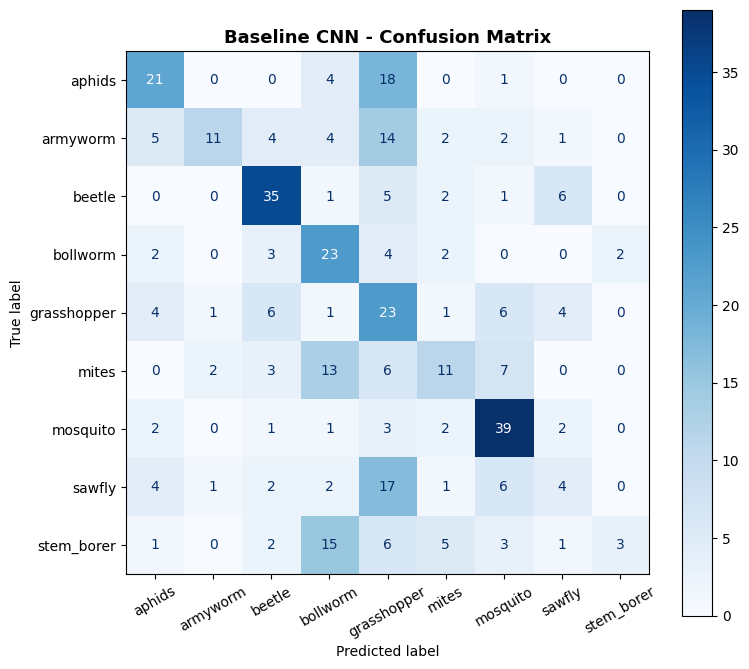

In [26]:
# Confusion Matrix - Baseline
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title('Baseline CNN - Confusion Matrix', fontsize=13, fontweight='bold')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('baseline_confusion_matrix.png', dpi=150)
plt.show()

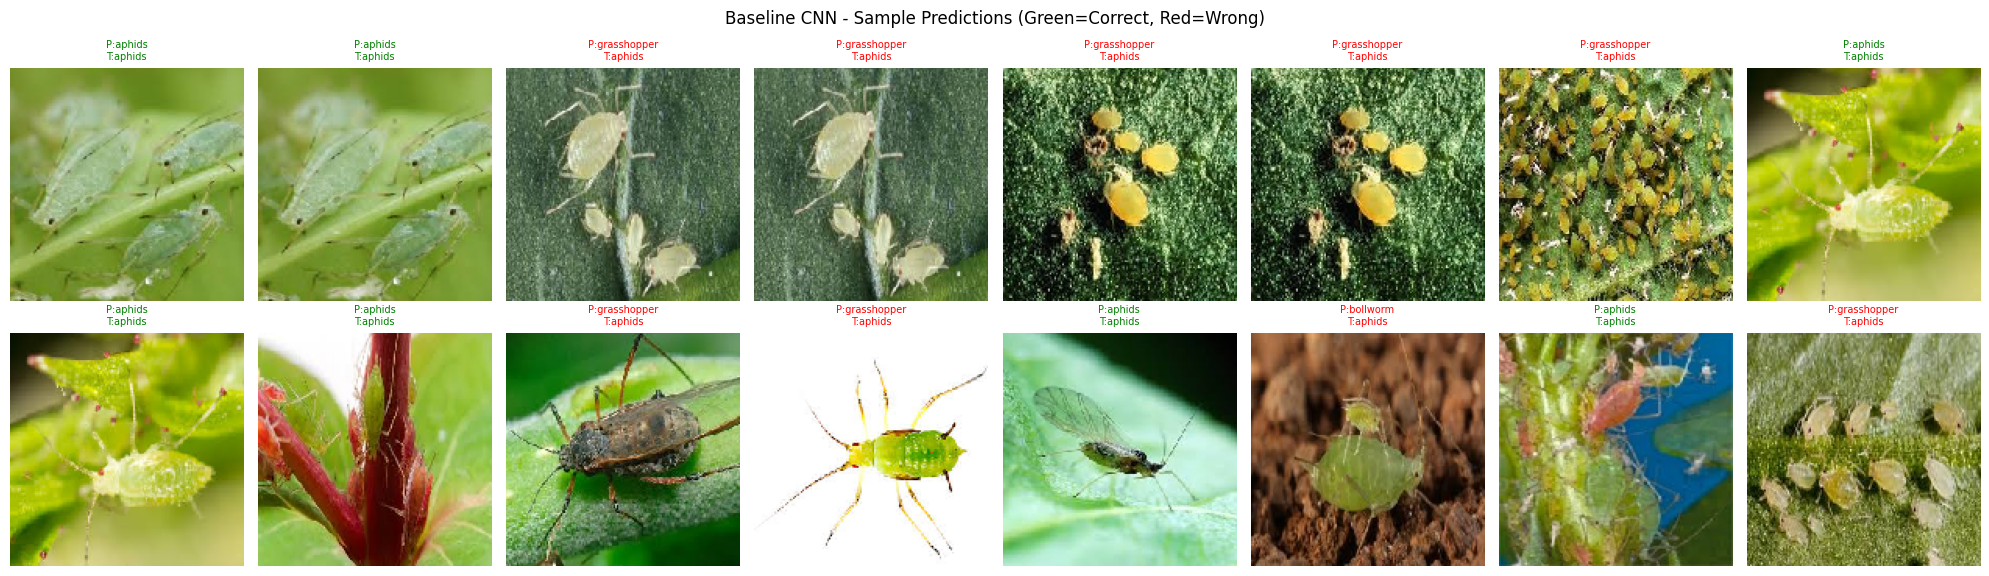

In [27]:
# Inference on sample test images
test_gen.reset()
sample_batch_imgs, sample_batch_labels = next(test_gen)

fig, axes = plt.subplots(2, 8, figsize=(20, 6))
for i, ax in enumerate(axes.flat):
    if i >= len(sample_batch_imgs): break
    pred_idx  = np.argmax(baseline_model.predict(sample_batch_imgs[i:i+1], verbose=0))
    true_idx  = np.argmax(sample_batch_labels[i])
    pred_cls  = CLASS_NAMES[pred_idx]
    true_cls  = CLASS_NAMES[true_idx]
    correct   = pred_idx == true_idx
    ax.imshow(sample_batch_imgs[i])
    ax.set_title(f'P:{pred_cls}\nT:{true_cls}',
                 fontsize=7,
                 color='green' if correct else 'red')
    ax.axis('off')

plt.suptitle('Baseline CNN - Sample Predictions (Green=Correct, Red=Wrong)', fontsize=12)
plt.tight_layout()
plt.savefig('baseline_predictions.png', dpi=150)
plt.show()

---
## 🧠 Feature Map Visualisation (Conv Layer Activations)
Shows what each convolutional layer *learns to see* — early layers detect edges and textures, deeper layers detect semantic patterns.

In [ ]:
# ── Feature Map Visualisation ────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import models as km

# Pick one test image
test_gen.reset()
sample_imgs, _ = next(test_gen)
sample_img = sample_imgs[0:1]   # shape (1, 150, 150, 3)

# Keras 3 compatible: use a dummy input to build the graph first
dummy = tf.keras.Input(shape=(150, 150, 3))
_ = baseline_model(dummy, training=False)   # forces the model to trace its graph

conv_layer_names = [l.name for l in baseline_model.layers if 'conv' in l.name]

# Build sub-models layer by layer using the functional API approach
activation_model = km.Model(
    inputs=baseline_model.input,
    outputs=[baseline_model.get_layer(n).output for n in conv_layer_names]
)

activations = activation_model.predict(sample_img, verbose=0)

fig, axes = plt.subplots(len(conv_layer_names), 8, figsize=(18, 3.5 * len(conv_layer_names)))

for layer_idx, (layer_act, layer_name) in enumerate(zip(activations, conv_layer_names)):
    n_filters = layer_act.shape[-1]
    idxs = np.linspace(0, n_filters - 1, 8, dtype=int)
    for col, f_idx in enumerate(idxs):
        ax = axes[layer_idx][col] if len(conv_layer_names) > 1 else axes[col]
        img = layer_act[0, :, :, f_idx]
        ax.imshow(img, cmap='viridis', aspect='auto')
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(layer_name, fontsize=8, rotation=0, labelpad=60)

plt.suptitle('Feature Maps – Baseline CNN Conv Layers (8 filters each)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_maps.png', dpi=150, bbox_inches='tight')
plt.show()


---
##  Part A - Section 3: Deeper CNN with Regularization
Architecture: **6 Conv layers + BatchNorm + Dropout**

In [28]:
def build_deep_model(input_shape=(150, 150, 3), num_classes=9):
    model = models.Sequential(name='Deep_CNN')

    # --- Block 1 ---
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    # --- Block 2 ---
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    # --- Block 3 ---
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    # --- Flatten & FCN ---
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(0.4))
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.3))

    # --- Output ---
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

deep_model = build_deep_model()
deep_model.summary()

Model: "Deep_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 150, 150, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 37, 37, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    21,234,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 21,690,409 (82.74 MB)

 Trainable params: 21,688,489 (82.74 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [29]:
# Compile and train deep model with Adam
deep_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_deep = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
]

start_time_deep = time.time()

history_deep = deep_model.fit(
    train_gen,
    epochs=EPOCHS_DEEP,
    validation_data=val_gen,
    callbacks=callbacks_deep,
    verbose=1
)

deep_train_time = time.time() - start_time_deep
print(f'\nDeep model training time (Adam): {deep_train_time:.1f}s ({deep_train_time/60:.1f} min)')

Epoch 1/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 56s 648ms/step - accuracy: 0.1602 - loss: 2.6415 - val_accuracy: 0.0668 - val_loss: 2.4268 - learning_rate: 0.0010
Epoch 2/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 303ms/step - accuracy: 0.1998 - loss: 2.2799 - val_accuracy: 0.1718 - val_loss: 2.3417 - learning_rate: 0.0010
Epoch 3/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 296ms/step - accuracy: 0.2394 - loss: 2.1041 - val_accuracy: 0.1337 - val_loss: 2.2393 - learning_rate: 0.0010
Epoch 4/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 293ms/step - accuracy: 0.2459 - loss: 2.0837 - val_accuracy: 0.1074 - val_loss: 2.2984 - learning_rate: 0.0010
Epoch 5/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 292ms/step - accuracy: 0.3156 - loss: 1.9211 - val_accuracy: 0.1002 - val_loss: 2.4076 - learning_rate: 0.0010
Epoch 6/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 309ms/step - accuracy: 0.3245 - loss: 1.9195 - val_accuracy: 0.2554 - val_loss: 2.0733 - learning_rate: 0.0010
Epoch 7/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 292ms/step - accuracy: 0.3357 - loss: 1.

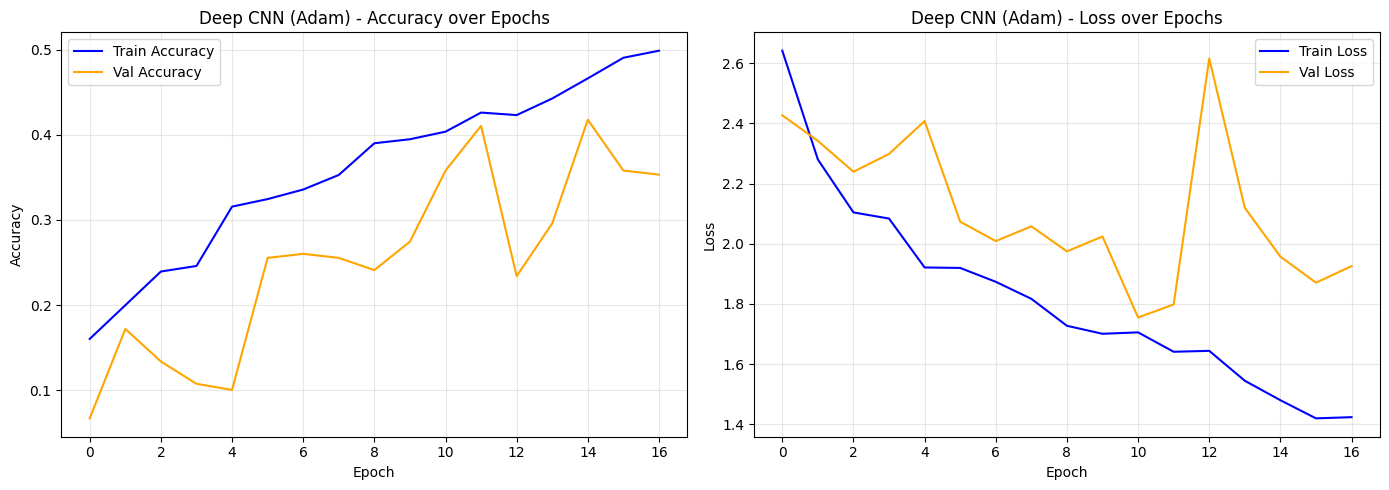

In [30]:
plot_history(history_deep, 'Deep CNN (Adam)')

=== DEEP MODEL EVALUATION (Adam) ===
Test Loss:     1.5232
Test Accuracy: 0.4661 (46.61%)
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      aphids       0.50      0.27      0.35        44
    armyworm       0.50      0.37      0.43        43
      beetle       0.77      0.80      0.78        50
    bollworm       0.41      0.67      0.51        36
 grasshopper       0.30      0.24      0.27        46
       mites       0.28      0.43      0.34        42
    mosquito       0.59      0.78      0.67        50
      sawfly       0.47      0.19      0.27        37
  stem_borer       0.34      0.33      0.34        36

    accuracy                           0.47       384
   macro avg       0.46      0.45      0.44       384
weighted avg       0.47      0.47      0.45       384



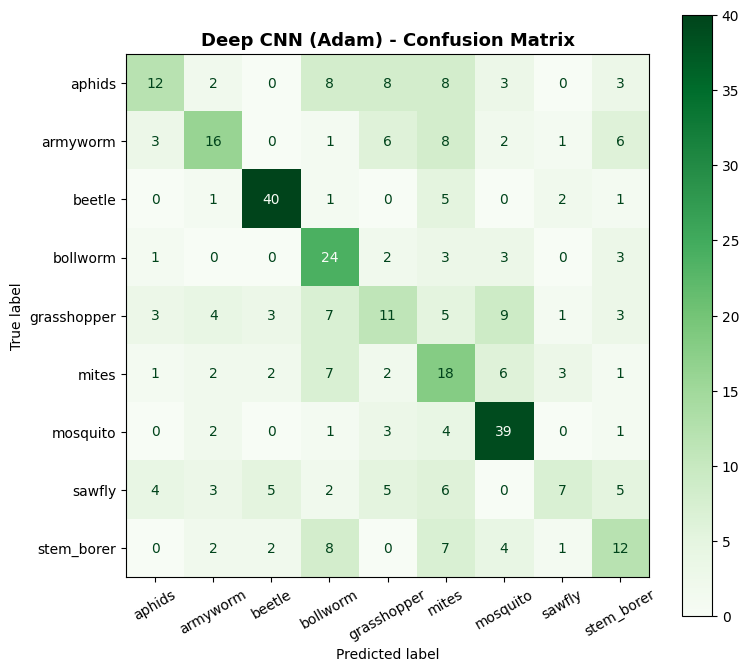

In [31]:
# Evaluate deep model
print('=== DEEP MODEL EVALUATION (Adam) ===')
deep_loss, deep_acc = deep_model.evaluate(test_gen, verbose=0)
print(f'Test Loss:     {deep_loss:.4f}')
print(f'Test Accuracy: {deep_acc:.4f} ({deep_acc*100:.2f}%)')

test_gen.reset()
y_pred_deep = np.argmax(deep_model.predict(test_gen, verbose=1), axis=1)
y_true      = test_gen.classes

print('\n=== CLASSIFICATION REPORT ===')
print(classification_report(y_true, y_pred_deep, target_names=CLASS_NAMES))

# Confusion matrix
cm_deep = confusion_matrix(y_true, y_pred_deep)
fig, ax = plt.subplots(figsize=(8,7))
ConfusionMatrixDisplay(cm_deep, display_labels=CLASS_NAMES).plot(ax=ax, cmap='Greens')
ax.set_title('Deep CNN (Adam) - Confusion Matrix', fontsize=13, fontweight='bold')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('deep_confusion_matrix.png', dpi=150)
plt.show()

---
## ⚡ Part A - Section 4: Optimizer Comparison — SGD vs Adam

In [32]:
# Train deep model with SGD
deep_model_sgd = build_deep_model()
deep_model_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_sgd = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

start_sgd = time.time()
history_sgd = deep_model_sgd.fit(
    train_gen,
    epochs=EPOCHS_DEEP,
    validation_data=val_gen,
    callbacks=callbacks_sgd,
    verbose=1
)
sgd_train_time = time.time() - start_sgd
print(f'\nSGD training time: {sgd_train_time:.1f}s ({sgd_train_time/60:.1f} min)')

Epoch 1/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 37s 486ms/step - accuracy: 0.1661 - loss: 2.5621 - val_accuracy: 0.2148 - val_loss: 6.1120 - learning_rate: 0.0100
Epoch 2/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 295ms/step - accuracy: 0.2287 - loss: 2.0710 - val_accuracy: 0.2434 - val_loss: 2.1588 - learning_rate: 0.0100
Epoch 3/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 17s 310ms/step - accuracy: 0.2612 - loss: 2.0306 - val_accuracy: 0.2625 - val_loss: 2.1707 - learning_rate: 0.0100
Epoch 4/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 294ms/step - accuracy: 0.2778 - loss: 1.9878 - val_accuracy: 0.2697 - val_loss: 2.0827 - learning_rate: 0.0100
Epoch 5/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 291ms/step - accuracy: 0.3150 - loss: 1.9053 - val_accuracy: 0.3055 - val_loss: 1.8810 - learning_rate: 0.0100
Epoch 6/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 289ms/step - accuracy: 0.3174 - loss: 1.9053 - val_accuracy: 0.2601 - val_loss: 1.9542 - learning_rate: 0.0100
Epoch 7/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 296ms/step - accuracy: 0.3097 - loss: 1.

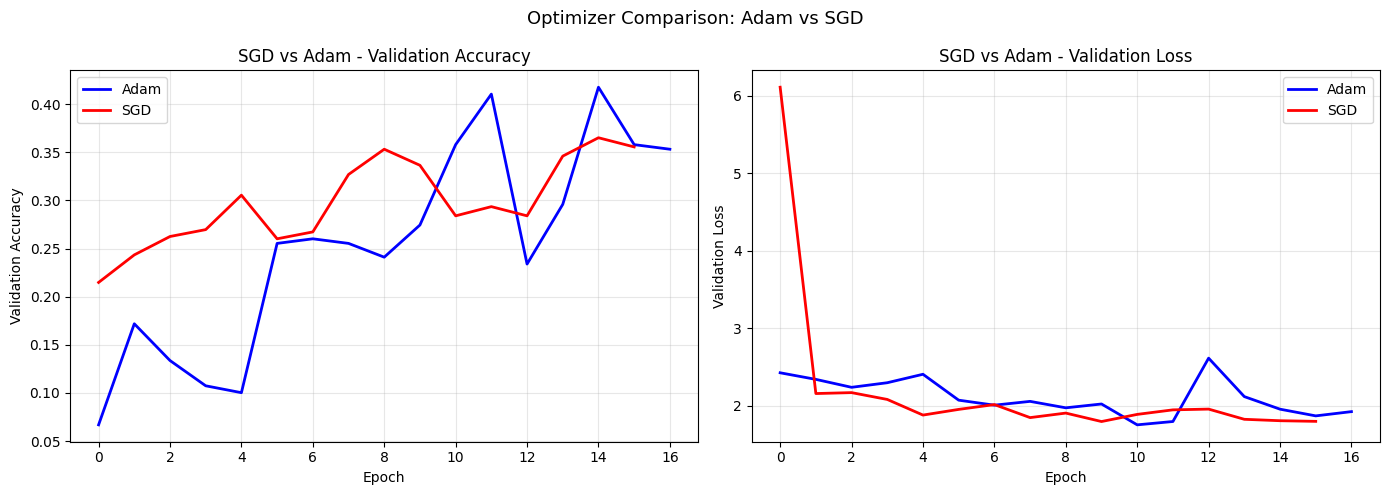

SGD  - Test Accuracy: 44.27%  |  Time: 4.5 min
Adam - Test Accuracy: 46.61%  |  Time: 5.1 min


In [33]:
# Compare SGD vs Adam
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history_deep.history['val_accuracy'], label='Adam', color='blue',   linewidth=2)
axes[0].plot(history_sgd.history['val_accuracy'],  label='SGD',  color='red',    linewidth=2)
axes[0].set_title('SGD vs Adam - Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history_deep.history['val_loss'], label='Adam', color='blue', linewidth=2)
axes[1].plot(history_sgd.history['val_loss'],  label='SGD',  color='red',  linewidth=2)
axes[1].set_title('SGD vs Adam - Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Optimizer Comparison: Adam vs SGD', fontsize=13)
plt.tight_layout()
plt.savefig('optimizer_comparison.png', dpi=150)
plt.show()

# Evaluate SGD
test_gen.reset()
sgd_loss, sgd_acc = deep_model_sgd.evaluate(test_gen, verbose=0)
print(f'SGD  - Test Accuracy: {sgd_acc*100:.2f}%  |  Time: {sgd_train_time/60:.1f} min')
print(f'Adam - Test Accuracy: {deep_acc*100:.2f}%  |  Time: {deep_train_time/60:.1f} min')

---
## 🔬 Part A - Section 5: Ablation Study
Remove Dropout and observe the effect

Epoch 1/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 31s 418ms/step - accuracy: 0.2199 - loss: 5.3281 - val_accuracy: 0.1122 - val_loss: 3.3331
Epoch 2/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 291ms/step - accuracy: 0.3298 - loss: 2.3507 - val_accuracy: 0.1695 - val_loss: 3.4593
Epoch 3/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 300ms/step - accuracy: 0.4178 - loss: 1.7643 - val_accuracy: 0.1432 - val_loss: 3.3300
Epoch 4/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 299ms/step - accuracy: 0.4882 - loss: 1.5745 - val_accuracy: 0.0859 - val_loss: 7.9706
Epoch 5/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 291ms/step - accuracy: 0.5496 - loss: 1.3666 - val_accuracy: 0.0931 - val_loss: 6.2101
Epoch 6/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 291ms/step - accuracy: 0.5946 - loss: 1.2469 - val_accuracy: 0.1504 - val_loss: 3.6715
Epoch 7/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 289ms/step - accuracy: 0.5940 - loss: 1.1804 - val_accuracy: 0.2100 - val_loss: 3.6487
Epoch 8/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 303ms/step - accuracy: 0.6318 - loss: 1.1061 - val_accu

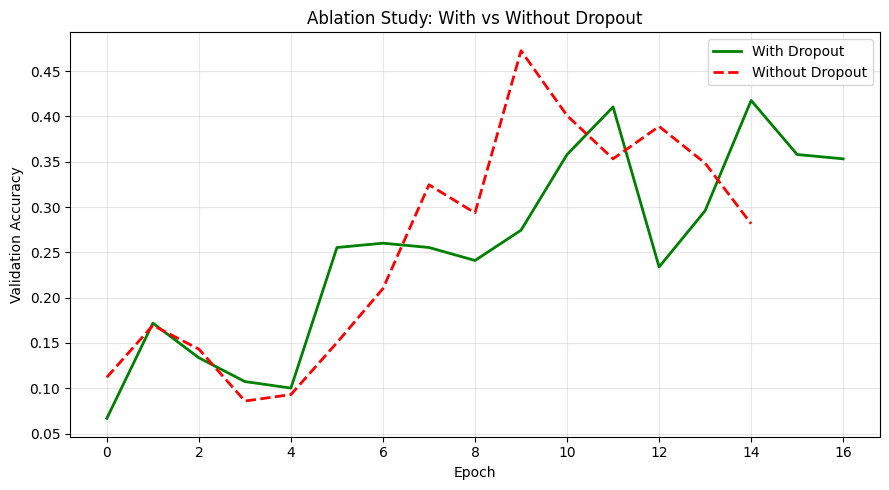

With Dropout:    46.61%
Without Dropout: 72.40%


In [34]:
# Deep model WITHOUT Dropout (ablation study)
def build_deep_no_dropout(input_shape=(150, 150, 3), num_classes=9):
    model = models.Sequential(name='Deep_CNN_No_Dropout')

    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

ablation_model = build_deep_no_dropout()
ablation_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_ablation = ablation_model.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)],
    verbose=1
)

# Compare with vs without dropout
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(history_deep.history['val_accuracy'],     label='With Dropout',    color='green', linewidth=2)
ax.plot(history_ablation.history['val_accuracy'], label='Without Dropout', color='red',   linewidth=2, linestyle='--')
ax.set_title('Ablation Study: With vs Without Dropout')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Accuracy')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('ablation_study.png', dpi=150)
plt.show()

test_gen.reset()
_, ablation_acc = ablation_model.evaluate(test_gen, verbose=0)
print(f'With Dropout:    {deep_acc*100:.2f}%')
print(f'Without Dropout: {ablation_acc*100:.2f}%')

---
## 🔍 Train vs Validation Gap Analysis (Overfitting Detector)
Plots the accuracy **gap** between training and validation over epochs for each model. A large gap signals overfitting.

In [ ]:
# ── Train–Val Gap Analysis ───────────────────────────────────────────────────
def plot_train_val_gap(histories, labels, colors):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    for hist, label, color in zip(histories, labels, colors):
        acc_gap  = [tr - va for tr, va in zip(hist.history['accuracy'],
                                               hist.history['val_accuracy'])]
        loss_gap = [va - tr for tr, va in zip(hist.history['loss'],
                                               hist.history['val_loss'])]
        ep = range(1, len(acc_gap) + 1)
        axes[0].plot(ep, acc_gap,  label=label, color=color, linewidth=2)
        axes[1].plot(ep, loss_gap, label=label, color=color, linewidth=2)

    for ax, title, ylabel in [
        (axes[0], 'Accuracy Gap (Train − Val): higher = more overfit', 'Accuracy Gap'),
        (axes[1], 'Loss Gap (Val − Train): higher = more overfit',     'Loss Gap'),
    ]:
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.fill_between(range(1, 30), 0, 0.15, alpha=0.05, color='red')
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

    plt.suptitle('Overfitting Analysis – Train vs Validation Gap', fontsize=13)
    plt.tight_layout()
    plt.savefig('overfitting_gap.png', dpi=150)
    plt.show()

plot_train_val_gap(
    [history_baseline, history_deep, history_sgd, history_ablation],
    ['Baseline (Adam)', 'Deep (Adam)', 'Deep (SGD)', 'No Dropout'],
    ['#4C72B0', '#55A868', '#DD8452', '#C44E52']
)


---
## 📊 Comparative Analysis: Baseline vs Deep Model

           MODEL COMPARISON SUMMARY
Model                       Test Acc   Train Time
------------------------------------------------------------
Baseline CNN (Adam)           44.27%        2.9m
Deep CNN (Adam)               46.61%        5.1m
Deep CNN (SGD)                44.27%        4.5m
Deep CNN (No Dropout)         72.40%          N/A


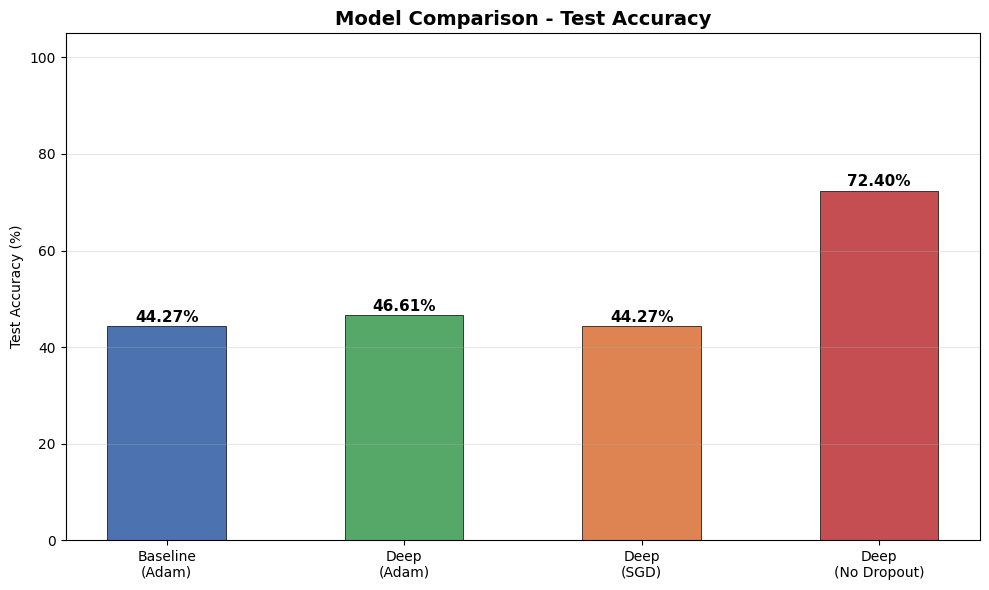

In [35]:
# Summary comparison table
print('=' * 60)
print('           MODEL COMPARISON SUMMARY')
print('=' * 60)
print(f'{"Model":<25} {"Test Acc":>10} {"Train Time":>12}')
print('-' * 60)
print(f'{"Baseline CNN (Adam)":<25} {baseline_acc*100:>9.2f}% {baseline_train_time/60:>10.1f}m')
print(f'{"Deep CNN (Adam)":<25} {deep_acc*100:>9.2f}% {deep_train_time/60:>10.1f}m')
print(f'{"Deep CNN (SGD)":<25} {sgd_acc*100:>9.2f}% {sgd_train_time/60:>10.1f}m')
print(f'{"Deep CNN (No Dropout)":<25} {ablation_acc*100:>9.2f}% {"N/A":>12}')
print('=' * 60)

# Bar chart comparison
models_names = ['Baseline\n(Adam)', 'Deep\n(Adam)', 'Deep\n(SGD)', 'Deep\n(No Dropout)']
accuracies   = [baseline_acc*100, deep_acc*100, sgd_acc*100, ablation_acc*100]
colors_bar   = ['#4C72B0', '#55A868', '#DD8452', '#C44E52']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(models_names, accuracies, color=colors_bar, edgecolor='black', linewidth=0.5, width=0.5)
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_ylim(0, 105)
ax.set_title('Model Comparison - Test Accuracy', fontsize=14, fontweight='bold')
ax.set_ylabel('Test Accuracy (%)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

---
## 🎯 Per-Class Accuracy Comparison
Breaks down model accuracy **per insect class** to reveal which classes are hard to classify.

In [ ]:
# ── Per-Class Accuracy – All Models ──────────────────────────────────────────
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

def per_class_accuracy(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    return cm.diagonal() / cm.sum(axis=1)

# Recompute all predictions fresh
test_gen.reset()
y_pred_baseline_cls = np.argmax(baseline_model.predict(test_gen, verbose=0), axis=1)
y_true_cls = test_gen.classes

test_gen.reset()
y_pred_deep_cls = np.argmax(deep_model.predict(test_gen, verbose=0), axis=1)

test_gen.reset()
y_pred_sgd_cls = np.argmax(deep_model_sgd.predict(test_gen, verbose=0), axis=1)

pca_baseline = per_class_accuracy(y_true_cls, y_pred_baseline_cls)
pca_deep     = per_class_accuracy(y_true_cls, y_pred_deep_cls)
pca_sgd      = per_class_accuracy(y_true_cls, y_pred_sgd_cls)

x = np.arange(len(CLASS_NAMES))
w = 0.22
fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(x - w, pca_baseline*100, w, label='Baseline',    color='#4C72B0', edgecolor='k', linewidth=0.4)
ax.bar(x,     pca_deep*100,     w, label='Deep (Adam)', color='#55A868', edgecolor='k', linewidth=0.4)
ax.bar(x + w, pca_sgd*100,      w, label='Deep (SGD)',  color='#DD8452', edgecolor='k', linewidth=0.4)

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=25, ha='right', fontsize=10)
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 110)
ax.set_title('Per-Class Accuracy – All Models', fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
ax.axhline(80, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150)
plt.show()


---
## 🚀 Part B: Transfer Learning - Fine-Tuning ResNet50

In [36]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

# Generator for transfer learning (224x224, ResNet preprocessing)
tl_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

tl_val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

tl_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

TL_IMG_SIZE = (224, 224)

tl_train_gen = tl_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=TL_IMG_SIZE, batch_size=32,
    class_mode='categorical', subset='training', shuffle=True, seed=42
)
tl_val_gen = tl_val_datagen.flow_from_directory(
    TRAIN_DIR, target_size=TL_IMG_SIZE, batch_size=32,
    class_mode='categorical', subset='validation', shuffle=False, seed=42
)
tl_test_gen = tl_test_datagen.flow_from_directory(
    TEST_DIR, target_size=TL_IMG_SIZE, batch_size=32,
    class_mode='categorical', shuffle=False
)

print('Transfer learning generators created!')

Found 1692 images belonging to 9 classes.
Found 419 images belonging to 9 classes.
Found 384 images belonging to 9 classes.
Transfer learning generators created!


In [37]:
# Load ResNet50 pretrained base (without top layer)
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze all base layers (Feature Extraction phase)
base_model.trainable = False

# Build new classification head
inputs  = keras.Input(shape=(224, 224, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(128, activation='relu')(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

tl_model = keras.Model(inputs, outputs, name='ResNet50_Transfer')
tl_model.summary()

print(f'\nTotal params:     {tl_model.count_params():,}')
print(f'Trainable params: {sum([tf.size(w).numpy() for w in tl_model.trainable_weights]):,}')

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


Model: "ResNet50_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,147,337 (92.11 MB)

 Trainable params: 559,113 (2.13 MB)

 Non-trainable params: 23,588,224 (89.98 MB)


Total params:     24,147,337
Trainable params: 559,113


In [ ]:
# Phase 1: Feature Extraction (frozen base)
tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_tl = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

start_tl = time.time()
history_tl_phase1 = tl_model.fit(
    tl_train_gen,
    epochs=10,
    validation_data=tl_val_gen,
    callbacks=callbacks_tl,
    verbose=1
)
print(f'\nPhase 1 done! Time: {(time.time()-start_tl)/60:.1f} min')

Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 60s 820ms/step - accuracy: 0.6200 - loss: 1.2194 - val_accuracy: 0.6969 - val_loss: 0.8449 - learning_rate: 0.0010
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 28s 520ms/step - accuracy: 0.8788 - loss: 0.3820 - val_accuracy: 0.7399 - val_loss: 0.7104 - learning_rate: 0.0010
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 28s 525ms/step - accuracy: 0.9096 - loss: 0.2651 - val_accuracy: 0.7804 - val_loss: 0.6887 - learning_rate: 0.0010
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 28s 520ms/step - accuracy: 0.9527 - loss: 0.1605 - val_accuracy: 0.8234 - val_loss: 0.7686 - learning_rate: 0.0010
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 28s 528ms/step - accuracy: 0.9657 - loss: 0.1116 - val_accuracy: 0.8401 - val_loss: 0.6820 - learning_rate: 0.0010
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 28s 523ms/step - accuracy: 0.9716 - loss: 0.0937 - val_accuracy: 0.8162 - val_loss: 0.6611 - learning_rate: 0.0010
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 28s 526ms/step - accuracy: 0.9758 - loss: 0.

In [ ]:
# Phase 2: Fine-Tuning (unfreeze last 30 layers)
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

print(f'Trainable layers after unfreeze: {sum(1 for l in tl_model.layers if l.trainable)}')

# Lower learning rate for fine-tuning
tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_finetune = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-8, verbose=1)
]

start_ft = time.time()
history_tl_phase2 = tl_model.fit(
    tl_train_gen,
    epochs=15,
    validation_data=tl_val_gen,
    callbacks=callbacks_finetune,
    verbose=1
)
tl_total_time = (time.time() - start_tl)
print(f'\nFine-tuning done! Total TL time: {tl_total_time/60:.1f} min')

Trainable layers after unfreeze: 9
Epoch 1/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 68s 826ms/step - accuracy: 0.9545 - loss: 0.1319 - val_accuracy: 0.8401 - val_loss: 0.6001 - learning_rate: 1.0000e-05
Epoch 2/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 28s 525ms/step - accuracy: 0.9728 - loss: 0.0837 - val_accuracy: 0.8019 - val_loss: 0.6225 - learning_rate: 1.0000e-05
Epoch 3/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 28s 523ms/step - accuracy: 0.9787 - loss: 0.0694 - val_accuracy: 0.7995 - val_loss: 0.6615 - learning_rate: 1.0000e-05
Epoch 4/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.9854 - loss: 0.0557
Epoch 4: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
53/53 ━━━━━━━━━━━━━━━━━━━━ 29s 539ms/step - accuracy: 0.9888 - loss: 0.0516 - val_accuracy: 0.7900 - val_loss: 0.6948 - learning_rate: 1.0000e-05
Epoch 5/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 28s 531ms/step - accuracy: 0.9876 - loss: 0.0467 - val_accuracy: 0.7804 - val_loss: 0.7104 - learning_rate: 3.0000e-06
Epoch 6/15
53/53 ━━━━━━━━━━━

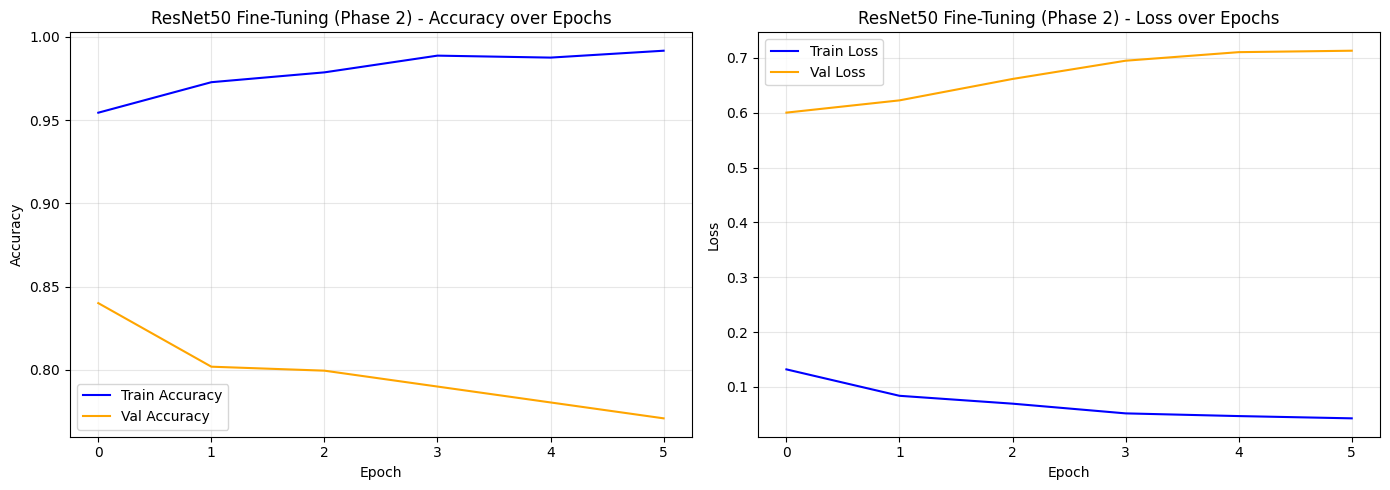

In [ ]:
# Plot transfer learning curves
plot_history(history_tl_phase2, 'ResNet50 Fine-Tuning (Phase 2)')

=== TRANSFER LEARNING MODEL EVALUATION ===
Test Loss:     0.1678
Test Accuracy: 0.9531 (95.31%)
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 156ms/step

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      aphids       0.98      0.91      0.94        44
    armyworm       0.93      0.95      0.94        43
      beetle       1.00      0.98      0.99        50
    bollworm       0.86      1.00      0.92        36
 grasshopper       1.00      1.00      1.00        46
       mites       0.95      0.95      0.95        42
    mosquito       0.98      0.96      0.97        50
      sawfly       0.91      0.84      0.87        37
  stem_borer       0.95      0.97      0.96        36

    accuracy                           0.95       384
   macro avg       0.95      0.95      0.95       384
weighted avg       0.95      0.95      0.95       384



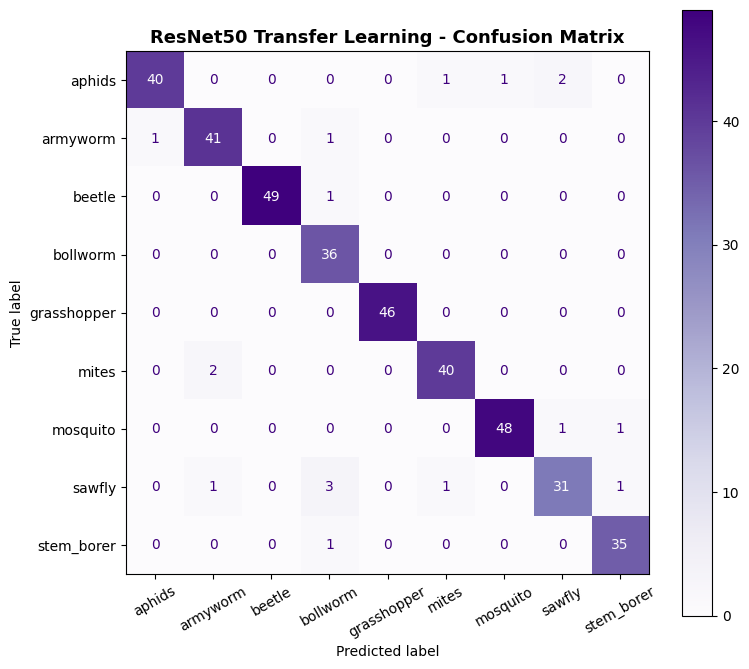

In [ ]:
# Evaluate transfer learning model
print('=== TRANSFER LEARNING MODEL EVALUATION ===')
tl_test_gen.reset()
tl_loss, tl_acc = tl_model.evaluate(tl_test_gen, verbose=0)
print(f'Test Loss:     {tl_loss:.4f}')
print(f'Test Accuracy: {tl_acc:.4f} ({tl_acc*100:.2f}%)')

tl_test_gen.reset()
y_pred_tl = np.argmax(tl_model.predict(tl_test_gen, verbose=1), axis=1)
y_true_tl = tl_test_gen.classes

print('\n=== CLASSIFICATION REPORT ===')
print(classification_report(y_true_tl, y_pred_tl, target_names=CLASS_NAMES))

# Confusion matrix
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
fig, ax = plt.subplots(figsize=(8,7))
ConfusionMatrixDisplay(cm_tl, display_labels=CLASS_NAMES).plot(ax=ax, cmap='Purples')
ax.set_title('ResNet50 Transfer Learning - Confusion Matrix', fontsize=13, fontweight='bold')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('tl_confusion_matrix.png', dpi=150)
plt.show()

---
## 📐 ROC Curves – One-vs-Rest (Best Model)
Plots the Receiver Operating Characteristic curve for each insect class using the best-performing model.

In [ ]:
# ── ROC Curves (One-vs-Rest) ─────────────────────────────────────────────────
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Use ResNet50 TL model (best)
tl_test_gen.reset()
y_scores = tl_model.predict(tl_test_gen, verbose=0)
y_true_bin = label_binarize(tl_test_gen.classes, classes=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(10, 7))
colors_roc = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))

for i, (cls, color) in enumerate(zip(CLASS_NAMES, colors_roc)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{cls} (AUC = {roc_auc:.2f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.50)')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves – ResNet50 Transfer Learning (One-vs-Rest)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()


---
## 📊 Precision-Recall Curves
Especially useful when classes are imbalanced — shows the trade-off between precision and recall per class.

In [ ]:
# ── Precision-Recall Curves ───────────────────────────────────────────────────
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 7))

for i, (cls, color) in enumerate(zip(CLASS_NAMES, colors_roc)):
    prec, rec, _ = precision_recall_curve(y_true_bin[:, i], y_scores[:, i])
    ap = average_precision_score(y_true_bin[:, i], y_scores[:, i])
    ax.plot(rec, prec, color=color, linewidth=2,
            label=f'{cls} (AP = {ap:.2f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves – ResNet50 Transfer Learning', fontsize=13, fontweight='bold')
ax.legend(loc='lower left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('precision_recall_curves.png', dpi=150)
plt.show()


---
## 🎲 Prediction Confidence Distribution
Histograms of the model's max predicted probability — a well-calibrated model is **confident when correct** and **uncertain when wrong**.

In [ ]:
# ── Confidence Distribution ───────────────────────────────────────────────────
test_gen.reset()
probs_baseline = baseline_model.predict(test_gen, verbose=0)
y_true_conf    = test_gen.classes
preds_baseline = np.argmax(probs_baseline, axis=1)
max_probs      = probs_baseline.max(axis=1)

correct_conf   = max_probs[preds_baseline == y_true_conf]
incorrect_conf = max_probs[preds_baseline != y_true_conf]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(correct_conf,   bins=30, alpha=0.7, color='#55A868', edgecolor='k', linewidth=0.4,
        label=f'Correct   (n={len(correct_conf)})')
ax.hist(incorrect_conf, bins=30, alpha=0.7, color='#C44E52', edgecolor='k', linewidth=0.4,
        label=f'Incorrect (n={len(incorrect_conf)})')
ax.axvline(0.5, color='black', linestyle='--', linewidth=1, label='50% confidence')
ax.set_xlabel('Max Predicted Probability (Confidence)', fontsize=12)
ax.set_ylabel('Count')
ax.set_title('Baseline CNN – Prediction Confidence Distribution', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('confidence_distribution.png', dpi=150)
plt.show()

print(f"Mean confidence – Correct:   {correct_conf.mean():.3f}")
print(f"Mean confidence – Incorrect: {incorrect_conf.mean():.3f}")


---
## 📊 Final Summary: All Models Compared

              FINAL MODEL COMPARISON SUMMARY
Model                           Test Accuracy   Train Time
-----------------------------------------------------------------
Baseline CNN (Adam)                    44.27%        2.9m
Deep CNN (Adam)                        46.61%        5.1m
Deep CNN (SGD)                         44.27%        4.5m
Deep CNN No Dropout (Adam)             72.40%          N/A
ResNet50 Transfer Learning             95.31%        8.6m


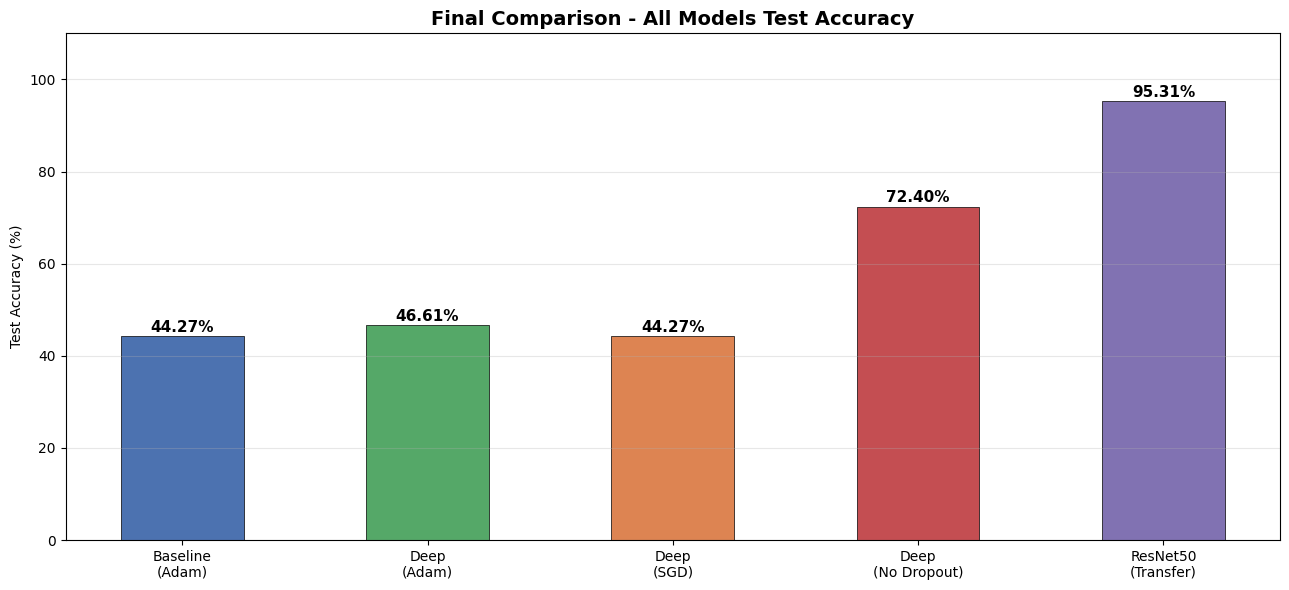

In [ ]:
print('=' * 65)
print('              FINAL MODEL COMPARISON SUMMARY')
print('=' * 65)
print(f'{"Model":<30} {"Test Accuracy":>14} {"Train Time":>12}')
print('-' * 65)
print(f'{"Baseline CNN (Adam)":<30} {baseline_acc*100:>13.2f}% {baseline_train_time/60:>10.1f}m')
print(f'{"Deep CNN (Adam)":<30} {deep_acc*100:>13.2f}% {deep_train_time/60:>10.1f}m')
print(f'{"Deep CNN (SGD)":<30} {sgd_acc*100:>13.2f}% {sgd_train_time/60:>10.1f}m')
print(f'{"Deep CNN No Dropout (Adam)":<30} {ablation_acc*100:>13.2f}% {"N/A":>12}')
print(f'{"ResNet50 Transfer Learning":<30} {tl_acc*100:>13.2f}% {tl_total_time/60:>10.1f}m')
print('=' * 65)

# Final bar chart
all_models = ['Baseline\n(Adam)', 'Deep\n(Adam)', 'Deep\n(SGD)',
              'Deep\n(No Dropout)', 'ResNet50\n(Transfer)']
all_accs   = [baseline_acc*100, deep_acc*100, sgd_acc*100, ablation_acc*100, tl_acc*100]
colors_all = ['#4C72B0','#55A868','#DD8452','#C44E52','#8172B2']

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(all_models, all_accs, color=colors_all, edgecolor='black', linewidth=0.5, width=0.5)
for bar, acc in zip(bars, all_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_ylim(0, 110)
ax.set_title('Final Comparison - All Models Test Accuracy', fontsize=14, fontweight='bold')
ax.set_ylabel('Test Accuracy (%)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150)
plt.show()

---
## 📉 Combined Loss Curve – All Models Overlaid
Visualises training loss convergence speed and smoothness for all models on one plot.

In [ ]:
# ── Combined Loss Overlay ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

model_histories = [
    (history_baseline, 'Baseline (Adam)', '#4C72B0', '-'),
    (history_deep,     'Deep (Adam)',     '#55A868', '-'),
    (history_sgd,      'Deep (SGD)',      '#DD8452', '--'),
    (history_ablation, 'No Dropout',      '#C44E52', ':'),
]

for hist, label, color, ls in model_histories:
    ep = range(1, len(hist.history['loss']) + 1)
    axes[0].plot(ep, hist.history['loss'],     color=color, linestyle=ls, linewidth=1.8, label=label)
    axes[1].plot(ep, hist.history['val_loss'], color=color, linestyle=ls, linewidth=1.8, label=label)

for ax, title in [
    (axes[0], 'Training Loss – All Models'),
    (axes[1], 'Validation Loss – All Models'),
]:
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle('Loss Convergence Comparison – All Models', fontsize=13)
plt.tight_layout()
plt.savefig('loss_convergence_all.png', dpi=150)
plt.show()


In [ ]:
# Save models
baseline_model.save('baseline_cnn.h5')
deep_model.save('deep_cnn_adam.h5')
tl_model.save('resnet50_transfer.h5')
print('All models saved successfully!')